In [1]:
import sys
import os
# please change the source path appropriately
srcpath = os.path.realpath('D:/400_AWT/400_setup_python/Tabor Library')
print(srcpath)
sys.path.append(srcpath)
from tevisainst import TEVisaInst
import matplotlib.pyplot as plt
import numpy as np
import time
from teproteus import TEProteusAdmin as TepAdmin
from teproteus_functions_v3 import get_cpatured_header
from teproteus_functions_v3 import connect, disconnect, convert_binoffset_to_signed, printProteusHeader

D:\400_AWT\400_setup_python\Tabor Library


In [2]:
def makeSqPulse(segLen, amp, phase, sampleRateDAC):
    """
    Make square pulse segment of length segLen
    
    Returns:
        dacWaveI: in-phase component
        dacWaveQ: quadrature component
    """
    assert segLen % 64 == 0, "segment length must be multiple of 64"
    ampI, ampQ = amp, amp
    dt = 1 / sampleRateDAC
    omega = 0
    time = np.arange(0, segLen - 0.5, 1)
    modWave = np.ones(segLen)
    max_dac = 2**16 - 1
    half_dac = np.floor(max_dac / 2)

    dacWaveI_modulation = ampI * np.cos(omega*time/segLen + np.pi*phase/180)
    dacWaveI = half_dac * (np.multiply(dacWaveI_modulation, modWave)+1)

    dacWaveQ_modulation = ampQ * np.sin(omega * time/segLen + np.pi * phase/180)
    dacWaveQ = half_dac * (np.multiply(dacWaveQ_modulation, modWave) + 1)

    return dacWaveI, dacWaveQ

In [3]:
def makeDC(segLen):
    """
    Make DC segment of length segLen
    
    Returns:
        dacWaveI: in-phase component
        dacWaveQ: quadrature component
    """
    assert segLen % 64 == 0, "segment length must be multiple of 64"
    max_dac = np.exp2(16) - 1
    half_dac = np.floor(max_dac/2)

    dacWave = np.zeros(segLen) + half_dac
    dacWaveI, dacWaveQ = dacWave.copy(), dacWave.copy()
    return dacWaveI, dacWaveQ

INITIALIZATION OF AWG

In [4]:
print("Initializing AWG...")
ch = 1
admin = TepAdmin() #required to control PXI module
slot_ids = admin.get_slot_ids()
sid = slot_ids[0]
inst = admin.open_instrument(slot_id=sid)
# inst = connect('192.168.0.121')
resp = inst.send_scpi_query("*IDN?")
resp = inst.send_scpi_cmd("*RST")
# set active channel
inst.send_scpi_cmd(f':INST:CHAN {ch}')
# pseudo command to use 16 bit mode
inst.send_scpi_cmd(':FREQ:RAST 2.5E9')
inst.send_scpi_cmd(':SOUR:VOLT MAX')
inst.send_scpi_cmd(':INIT:CONT ON')
inst.send_scpi_cmd(':TRAC:DEL:ALL')
print("AWG Initialization done.")

Initializing AWG...
Load TEProteus.dll from : C:\Windows\system32\TEProteus.dll
AWG Initialization done.


202496


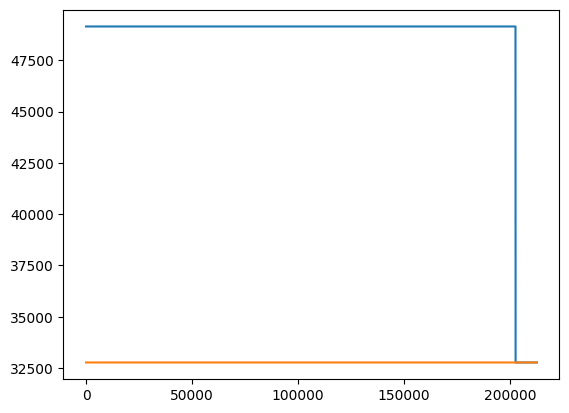

In [ ]:
sampleRateDAC = 675e6
interp_factor = 8
spacing_t, pulse_t = 15e-6, 300e-6
cfr, phase = 75.38e6, 90
num_Pulses = 3e5
spacingPt = sampleRateDAC * spacing_t // 64 * 64
lengthPt = sampleRateDAC * pulse_t // 64 * 64
spacingPt, lengthPt = int(spacingPt), int(lengthPt)
spacing_I, spacing_Q = makeDC(spacingPt)
mark_DC, mark_DC2 = np.zeros(spacingPt), np.zeros(spacingPt)
ON_I, ON_Q = makeSqPulse(segLen = lengthPt, amp = 0.5, phase = 0, sampleRateDAC = sampleRateDAC)
pulse_I, pulse_Q = np.concatenate((ON_I, spacing_I)), np.concatenate((ON_Q, spacing_Q))
# GENERATE MARKERS

mark_IQ, mark_IQ2  = np.zeros(lengthPt) + 1, np.zeros(lengthPt) + 1
pulse_I, pulse_Q = np.concatenate((ON_I, spacing_I)), np.concatenate((ON_Q, spacing_Q))
mark1, mark2 = np.concatenate((mark_IQ, mark_DC)).astype(np.uint8), np.concatenate((mark_IQ2, mark_DC2)).astype(np.uint8)
x = range(len(pulse_I))
print(len(ON_I))
plt.plot(x, pulse_I, x, pulse_Q)

# x=range((int)(readLen / 4))
    # print(len(wave_i))
    # plt.plot(x, wave_q, x, wave_i)
    # plt.show


Download waveforms

In [6]:
segMem = 1
print(f"Downloading waveform to channel {ch}, segment {segMem}")
res = inst.send_scpi_cmd(f':INST:CHAN {ch}')
dacWave_IQ = np.vstack((pulse_I, pulse_Q)).reshape((-1,), order = 'F')
inst.send_scpi_cmd(f':TRAC:FORM U16')
inst.send_scpi_cmd(f':TRAC:DEF {segMem}, {len(dacWave_IQ)}')
inst.send_scpi_cmd(f':TRAC:SEL {segMem}')

# Download the binary data to segment
prefix = '*OPC?; :TRAC:DATA'
myWfm = dacWave_IQ.astype(np.uint16)
inst.timeout = 30000
inst.write_binary_data(prefix, myWfm)
inst.timeout = 10000
resp = inst.send_scpi_query(':SYST:ERR?')
assert int(resp.split(',')[0]) == 0, f"IQ segment not downloaded correctly. Error code: {resp}"

Download Markers

In [7]:
print(f"Downloading marker to channel: {ch}, segment: {segMem} \n")
myMkr = np.uint8(mark1 + 2*mark2)

# set DAC channel
res = inst.send_scpi_cmd(f':INST:CHAN {ch}')
assert res == 0, "channel not correctly set"
inst.send_scpi_cmd(f":TRAC:SEL {segMem}")

myMkr = myMkr[0::2] + 16 * myMkr[1::2]
myMkr = myMkr.astype(np.uint8)
prefix = ':MARK:DATA 0,'
inst.write_binary_data(prefix, myMkr)
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)
assert int(resp.split(',')[0]) == 0
inst.send_scpi_cmd(':MARK:SEL 1')
inst.send_scpi_cmd(':MARK:STAT ON')
inst.send_scpi_cmd(':MARK:SEL 2')
inst.send_scpi_cmd(':MARK:STAT ON')


0, no error


0

Generate Task Table

In [8]:
print("generate task table")
inst.send_scpi_cmd(f':INST:CHAN {ch}')
inst.send_scpi_cmd('TASK:ZERO:ALL')
inst.send_scpi_cmd(f':TASK:COMP:LENG 1')
inst.send_scpi_cmd(f':TASK:COMP:SEL 1')
inst.send_scpi_cmd(f':TASK:COMP:LOOP {num_Pulses}')
inst.send_scpi_cmd(':TASK:COMP:ENAB CPU')
inst.send_scpi_cmd(f':TASK:COMP:SEGM 1')
inst.send_scpi_cmd(f':TASK:COMP:NEXT1 1')
inst.send_scpi_cmd(':TASK:COMP:TYPE SING')
inst.send_scpi_cmd(':TASK:COMP:WRITE')
inst.send_scpi_cmd(':SOUR:FUNC:MODE TASK')

generate task table


0

In [9]:
print("Setting NCO IQ modulation...")
inst.send_scpi_cmd(f':INST:CHAN {ch}')
# pseudo command to use 16 bit mode, also for IQ Modulation
inst.send_scpi_cmd(':FREQ:RAST 2.5E9')

inst.send_scpi_cmd(f':SOUR:INT X{interp_factor}')

inst.send_scpi_cmd(':MODE DUC')
inst.send_scpi_cmd(':IQM ONE')
# multiply sampleRateDAC by 8 -- the interpolation factor -- and set it to AWG.
sampleRateDAC = sampleRateDAC * interp_factor
inst.send_scpi_cmd(f':FREQ:RAST {sampleRateDAC}')
inst.send_scpi_cmd(':SOUR:NCO:SIXD1 ON')
inst.send_scpi_cmd(f':SOUR:NCO:CFR1 {cfr}')
inst.send_scpi_cmd(f':SOUR:NCO:PHAS1 {phase}')
resp = inst.send_scpi_cmd(':OUTP ON')
assert resp == 0, "NCO not correctly set"
print("NCO IQ modulation set.")

Setting NCO IQ modulation...
NCO IQ modulation set.


START DIGITIZER

In [10]:
# MODE 0: reading out frames, MODE 1: reading out Header
# Set to readout header or the full frame
MODE = 0

if MODE == 0:
    ret = inst.send_scpi_cmd(':DIG:ACQ:TYPE ALL')
elif MODE == 1:
    ret = inst.send_scpi_cmd(':DIG:ACQ:TYPE HEAD')  # ALL / HEADers

ret = inst.send_scpi_query(':DIG:ACQ:TYPE?')
print(ret)

ALL


In [11]:
sampleRateADC = sampleRateDAC / 4
numframes = num_Pulses
tacq = 8
# readLen = int(8*1e-6*(2.7*1e9)/4) // 96 * 96
readLen = 56*36 # = 2016, largest transmission length with granularity of 36 and below 2048/4 for DSP capturing length
cmd = ':DIG:MODE DUAL'
inst.send_scpi_cmd(cmd)
print('ADC Clk Freq {0}'.format(sampleRateADC))
cmd = ':DIG:FREQ  {0}'.format(sampleRateADC)
inst.send_scpi_cmd(cmd)
resp = inst.send_scpi_query(':DIG:FREQ?')
print("Dig Frequency = ")
print(resp)

# Enable capturing data from channel 1
cmd = ':DIG:CHAN:SEL 1'
inst.send_scpi_cmd(cmd)
resp = inst.send_scpi_query(':SYST:ERR?')
print("Dig error = ")
print(resp)
# DDC activation to complex i+jq
inst.send_scpi_cmd(':DIG:DDC:MODE COMP')
inst.send_scpi_cmd(':DIG:DDC:CFR1 {0}'.format(cfr))
inst.send_scpi_cmd(':DIG:DDC:PHAS1 90')
inst.send_scpi_cmd(':DIG:DDC:CLKS AWG')
resp = inst.send_scpi_query(':SYST:ERR?')
print("Set complex error = ")
print(resp)
inst.send_scpi_cmd(':DIG:CHAN:STATE ENAB')

# trigger from external source
inst.send_scpi_cmd(':DIG:TRIG:SOUR EXT')
inst.send_scpi_cmd(':DIG:TRIG:SLOP NEG')
inst.send_scpi_cmd(':DIG:TRIG:LEV1 1')
inst.send_scpi_cmd(f':DIG:TRIG:DEL:EXT {12e-6}' )
resp = inst.send_scpi_query(':SYST:ERR?')
print("Set complex error = ")
print(resp)

print(f"numframes = {numframes}, readLen = {readLen}")
inst.send_scpi_cmd(':DIG:ACQ:DEF {0},{1}'.format(numframes, 2*readLen))
# inst.send_scpi_cmd(':DIG:ACQ:DEF {0},{1}'.format(numframes, readLen))
# inst.send_scpi_cmd(f':DIG:ACQ:FRAM:CAPT 1, {numframes}')
inst.send_scpi_cmd(':DIG:ACQ:FRAM:CAPT:ALL')
inst.send_scpi_cmd(':DIG:ACQ:ZERO:ALL')

################################################################################
# Start the digitizer's capturing machine
inst.send_scpi_cmd(':DIG:INIT OFF')
inst.send_scpi_cmd(':DIG:INIT ON')

ADC Clk Freq 1350000000.0
Dig Frequency = 
1350000000.000
Dig error = 
0, no error
Set complex error = 
0, no error
Set complex error = 
0, no error
numframes = 30000.0, readLen = 2016


0

In [12]:
# Enable capturing data from DDR 1
inst.send_scpi_cmd(':DIG:CHAN:SEL 1')
inst.send_scpi_cmd(':DIG:CHAN:STATE ENAB')
inst.send_scpi_cmd(':DIG:CHAN:RANGe {0}'.format("HIGH"))

# Enable capturing data from DDR 2
inst.send_scpi_cmd(':DIG:CHAN:SEL 2')
inst.send_scpi_cmd(':DIG:CHAN:STATE ENAB')
inst.send_scpi_cmd(':DIG:CHAN:RANGe {0}'.format("HIGH"))

inst.send_scpi_cmd(':DIG:DDC:BIND ON')

0

In [13]:
print(sampleRateADC)
print(sampleRateDAC)

1350000000.0
5400000000.0


In [14]:
# Select to store the DSP1 data
inst.send_scpi_cmd(':DSP:STOR DSP')  # DIRect | DSP | FFT
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

# dsp decision frame
inst.send_scpi_cmd(':DSP:DEC:FRAM {0}'.format(readLen / 4))
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)


0, no error
0, no error


In [15]:
# inst.send_scpi_query(':DSP:FIR:BYPass ON')

In [16]:
print("waiting for input ...")
input()
resp = inst.send_scpi_query(':DIG:ACQuire:FRAM:STATus?')
print(resp)
inst.send_scpi_cmd('*TRG')
max_iter = 120
frameRx = 0
times = 0
FRAME_NMB = numframes
while (frameRx < FRAME_NMB):
    # inst.send_scpi_cmd(':DIG:TRIG:IMM')
    resp = inst.send_scpi_query(':DIG:ACQuire:FRAM:STATus?')
    print(resp)
    framesParam = resp.split(",")
    frameRx = int(framesParam[3])
    times += 1
    time.sleep(0.1)
    if times > max_iter:
        break
print(resp)
inst.send_scpi_cmd(':DIG:INIT OFF')


waiting for input ...
1,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,0,0,0
0,

0

In [17]:
if MODE == 0:
    # Choose which frames to read (all in this example)
    inst.send_scpi_cmd(':DIG:DATA:SEL ALL')

    # Choose what to read 
    # (BOTH for frames and headers, FRAM only the frame-data without the header)
    inst.send_scpi_cmd(':DIG:DATA:TYPE FRAM')

    # Get the total data size (in bytes)
    resp = inst.send_scpi_query(':DIG:DATA:SIZE?')
    num_bytes = np.uint32(resp)
    print('Total size in bytes: ' + resp)

    # Read the data that was captured by DDR 1:
    inst.send_scpi_cmd(':DIG:CHAN:SEL 2')
    # because read format is UINT16 we divide byte number by 2
    wavlen = num_bytes // 2
    wav1 = np.zeros(wavlen, dtype=np.uint16)
    rc = inst.read_binary_data(':DIG:DATA:READ?', wav1, num_bytes)
    resp = inst.send_scpi_query(':SYST:ERR?')
    print(resp)
    print("read data from DDR1")


Total size in bytes: 241920000
0, no error
read data from DDR1


In [18]:
if MODE == 0:
     read = time.time()
     # Choose what to read
     ret = inst.send_scpi_cmd(':DIG:DATA:TYPE HEAD')
     ret = inst.send_scpi_query(':DIG:DATA:TYPE?')
     print(ret)
     header_size=88
     num_bytes = numframes * header_size
     print('Total Headers size in bytes: {0} '.format(num_bytes))
     header = np.zeros(int(num_bytes), dtype=np.uint8)
     # Read the data that was captured by DDR 1:
     inst.send_scpi_cmd(':DIG:CHAN:SEL 2')
     rc = inst.read_binary_data(':DIG:DATA:READ?', header, num_bytes)
     print("Length of the header buffer")
     print(len(header))
     print("First 800 points of the header")
     print(header[:800])
     

HEAD
Total Headers size in bytes: 2640000.0 
Length of the header buffer
2640000
First 800 points of the header
[  0   0   0   0   0   0   0   0   0   0   0   0 130   0   0   0 226 197
  81 168 234 173   5   0  99  62  11   0 197 143 254 255 149 255 255 255
  62 255 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0 168   0   0   0   2 212  85 168
 234 173   5   0   3  64  11   0 113 143 254 255  45 255 255 255 138 255
 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0 120   0   0   0  34 226  89 168 234 173
   5   0 143  61  11   0 201 143 254 255  38 255 255 255 246 255 255 255
   0   0   0

In [19]:
proteus_header = get_cpatured_header(printHeader=True,N=256,buf=header,dspEn=True)
printProteusHeader(proteus_header, 2)

header# 0
TriggerPos: 0
GateLength: 0
Min Amp: 0.0
Max Amp: 65.0
TimeStamp: 1598598241437154
Decision1: 736867 + j* -94267
Decision2: -107 + j* -194
Decision3: 0 + j* 0
Decision4: 0 + j* 0
Decision5: 0 + j* 0
STATE1: 0
STATE2: 0
STATE3: 0
STATE4: 0
STATE5: 0

header# 2
TriggerPos: 0
GateLength: 0
Min Amp: 0.0
Max Amp: 60.0
TimeStamp: 1598598241968674
Decision1: 736655 + j* -94263
Decision2: -218 + j* -10
Decision3: 0 + j* 0
Decision4: 0 + j* 0
Decision5: 0 + j* 0
STATE1: 0
STATE2: 0
STATE3: 0
STATE4: 0
STATE5: 0



504
1463.0 0x5b7 ,  5b7
1461.0 0x5b5 ,  b6c
1458.0 0x5b2 ,  111e
1459.0 0x5b3 ,  16d1
1463.0 0x5b7 ,  1c88
1466.0 0x5ba ,  2242
1465.0 0x5b9 ,  27fb
1463.0 0x5b7 ,  2db2
1463.0 0x5b7 ,  3369
1466.0 0x5ba ,  3923
1468.0 0x5bc ,  3edf
1466.0 0x5ba ,  4499
1463.0 0x5b7 ,  4a50
1462.0 0x5b6 ,  5006
1465.0 0x5b9 ,  55bf
1468.0 0x5bc ,  5b7b
1467.0 0x5bb ,  6136
1465.0 0x5b9 ,  66ef
1464.0 0x5b8 ,  6ca7
1464.0 0x5b8 ,  725f
1464.0 0x5b8 ,  7817
1463.0 0x5b7 ,  7dce
1461.0 0x5b5 ,  8383
1460.0 0x5b4 ,  8937
1459.0 0x5b3 ,  8eea
1458.0 0x5b2 ,  949c
1459.0 0x5b3 ,  9a4f
1462.0 0x5b6 ,  a005
1464.0 0x5b8 ,  a5bd
1465.0 0x5b9 ,  ab76
1466.0 0x5ba ,  b130
1466.0 0x5ba ,  b6ea
1467.0 0x5bb ,  bca5
1466.0 0x5ba ,  c25f
1463.0 0x5b7 ,  c816
1461.0 0x5b5 ,  cdcb
1461.0 0x5b5 ,  d380
1463.0 0x5b7 ,  d937
1465.0 0x5b9 ,  def0
1467.0 0x5bb ,  e4ab
1467.0 0x5bb ,  ea66
1467.0 0x5bb ,  f021
1465.0 0x5b9 ,  f5da
1464.0 0x5b8 ,  fb92
1463.0 0x5b7 ,  10149
1463.0 0x5b7 ,  10700
1461.0 0x5b5 ,  10cb5
1459.0 0

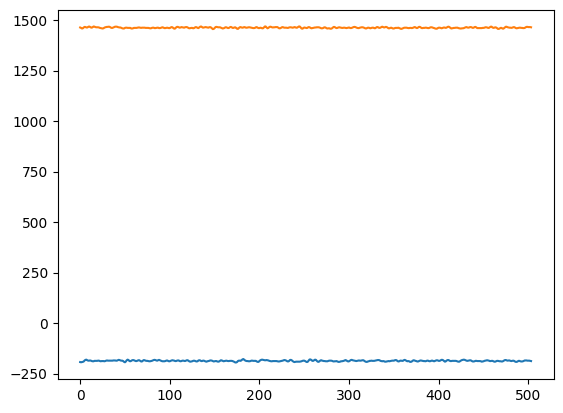

In [20]:
if MODE == 0:
    # wav1 = np.int32(wav1)
    wave_q = wav1[0:readLen:4]
    wave_i = wav1[1:readLen:4]
    
    wave_q = np.floor((wave_q / 2))
    wave_i = np.floor((wave_i / 2))
    
    # x=range((int)(readLen / 4))
    # print(len(wave_i))
    # plt.plot(x, wave_q, x, wave_i)
    # plt.show

    wave_q = convert_binoffset_to_signed(wave_q, 15)
    wave_i = convert_binoffset_to_signed(wave_i, 15)
    
    x=range((int)(readLen / 4))
    print(len(wave_i))
    plt.plot(x, wave_q, x, wave_i)
    plt.show


    # for i in range(500):
    #     print(format(wav1[i], 'x'))
    sum = 0
    for i in range((int)(readLen / 4)):
        sum = sum + wave_i[i]
        print(wave_i[i], format((int)(wave_i[i]), '#x'), ', ', format((int)(sum), 'x'))
    print(np.sum(wave_i[:(int)(readLen / 4)]))
    print(np.sum(wave_q[:(int)(readLen / 4)]))
    # wave = wav1[0::2] - 16384
    # samplesI = wave[0::2]
    # samplesQ = wave[1::2]
    # samples = samplesI + 1j *samplesQ
    # print(readLen)
    # print(samples)
    # print(samples[0: readLen])

    # # frame_idx ranges from 0 to FRAME_NMB-1 (decides on which frame to readout)
    # # samples is 8 times larger because 2 bytes is 16 bits and we download it
    # # and every other is a valid data point. With alternating I and Q
    # frame_idx = FRAME_NMB - 2
    # print(3e4*readLen)
    # print(samples[int(frame_idx*readLen): int((frame_idx+1)*readLen)])


In [21]:
inst.close_instrument()
# admin.close_inst_admin()